# Lecture 11 — Slice Selection (runnable notebook)

**Module 2 · ROADMAP Day 13** — companion to `L11_summary.md`.

This notebook *builds* slice selection from scratch on synthetic data:

1. Larmor frequency as a position label (the gradient)
2. Slice **position** and the `x₁` formula
3. Slice **thickness** and the `Δx ∝ 1/G` law
4. **Oblique** slices (plane ⊥ **G**)
5. The **sinc** RF pulse and the rect↔sinc Fourier pair (+ truncation)
6. A **Bloch slice-profile simulation**: small- vs large-flip (the small-flip-angle approximation)
7. The **slice-rephasing gradient**
8. **Exercise 11.1** (numbers) and **Exercise 11.2** (the "gymnastics") worked in code

> **How to use it:** run cell-by-cell, then *change things* — field strength, gradient amplitude, bandwidth, flip angle — and watch the plots move. That's where the learning happens.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Proton gyromagnetic ratio
GAMMA     = 2.6752218744e8        # rad / s / T
GAMMA_BAR = GAMMA / (2*np.pi)     # Hz / T   (= 42.577e6)
print(f"gamma_bar = {GAMMA_BAR/1e6:.3f} MHz/T")
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": .3})

gamma_bar = 42.577 MHz/T


## 1 · A gradient turns frequency into a position label

With an x-gradient on, the local Larmor frequency is

$$\omega(x) = \omega_0 + \gamma G_x x \quad\Longleftrightarrow\quad (\nu - \nu_0) = \bar\gamma\,G_x x .$$

A stronger gradient = a steeper line = frequency changes faster with position.

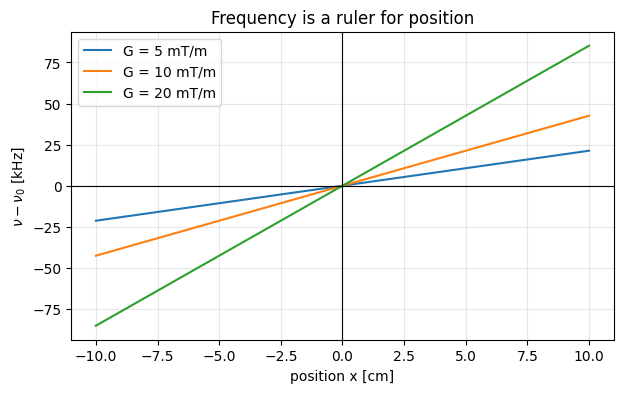

In [2]:
def larmor_offset_Hz(G_Tm, pos_m):
    # Frequency offset (nu - nu0) for a 1-D gradient [Hz]
    return GAMMA_BAR * G_Tm * pos_m

x = np.linspace(-0.10, 0.10, 400)          # +/- 10 cm
plt.figure()
for G in (5e-3, 10e-3, 20e-3):
    plt.plot(x*100, larmor_offset_Hz(G, x)/1e3, label=f"G = {G*1e3:.0f} mT/m")
plt.axhline(0, color="k", lw=.8); plt.axvline(0, color="k", lw=.8)
plt.xlabel("position x [cm]"); plt.ylabel(r"$\nu-\nu_0$ [kHz]")
plt.title("Frequency is a ruler for position"); plt.legend(); plt.show()

## 2 · Slice position

Transmit at `ω_HF`; only the position whose local frequency matches is excited:

$$x_1 = \frac{1}{\gamma G_x}\,(\omega_{\mathrm{HF}}-\omega_0).$$

To excite x1 = 3.0 cm with G = 10 mT/m, transmit (nu_HF - nu0) = 12.77 kHz
Round-trip position = 3.00 cm


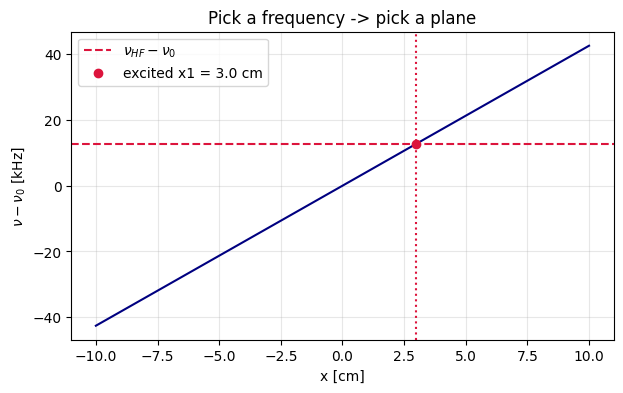

In [3]:
def slice_position_m(df_Hz, G_Tm):
    return df_Hz / (GAMMA_BAR * G_Tm)

G_x = 10e-3                  # mT/m
target_cm = 3.0
df = larmor_offset_Hz(G_x, target_cm/100)
print(f"To excite x1 = {target_cm} cm with G = {G_x*1e3:.0f} mT/m, "
      f"transmit (nu_HF - nu0) = {df/1e3:.2f} kHz")
print(f"Round-trip position = {slice_position_m(df, G_x)*100:.2f} cm")

plt.figure()
plt.plot(x*100, larmor_offset_Hz(G_x, x)/1e3, color="navy")
plt.axhline(df/1e3, color="crimson", ls="--", label=r"$\nu_{HF}-\nu_0$")
plt.axvline(target_cm, color="crimson", ls=":")
plt.plot(target_cm, df/1e3, "o", color="crimson", label=f"excited x1 = {target_cm} cm")
plt.xlabel("x [cm]"); plt.ylabel(r"$\nu-\nu_0$ [kHz]")
plt.title("Pick a frequency -> pick a plane"); plt.legend(); plt.show()

## 3 · Slice thickness and the `Δx ∝ 1/G` law

A *band* of frequencies `Δν` excites a *slab*:

$$\Delta x = \frac{\Delta\omega}{\gamma G_x}\quad\Rightarrow\quad \Delta x \propto G_x^{-1}.$$

Stronger gradient → **thinner** slice (at fixed bandwidth). This is a pop-quiz favourite.

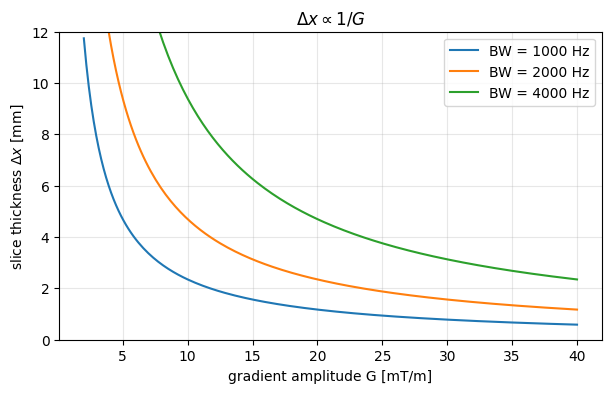

Δx at BW=1 kHz, G=10 mT/m : 2.35 mm
BW needed for 2 mm @ 10 mT/m: 852 Hz


In [4]:
def slice_thickness_m(bw_Hz, G_Tm):
    return bw_Hz / (GAMMA_BAR * abs(G_Tm))
def bandwidth_Hz(dx_m, G_Tm):
    return GAMMA_BAR * abs(G_Tm) * dx_m

G_arr = np.linspace(2e-3, 40e-3, 200)
plt.figure()
for bw in (1000, 2000, 4000):
    plt.plot(G_arr*1e3, slice_thickness_m(bw, G_arr)*1e3, label=f"BW = {bw} Hz")
plt.xlabel("gradient amplitude G [mT/m]"); plt.ylabel(r"slice thickness $\Delta x$ [mm]")
plt.title(r"$\Delta x \propto 1/G$"); plt.legend(); plt.ylim(0, 12); plt.show()

print(f"Δx at BW=1 kHz, G=10 mT/m : {slice_thickness_m(1000,10e-3)*1e3:.2f} mm")
print(f"BW needed for 2 mm @ 10 mT/m: {bandwidth_Hz(2e-3,10e-3):.0f} Hz")

## 4 · Oblique slices: the plane is ⊥ **G**

Use all three channels. The resonance condition becomes a dot product, and the excited
plane sits at signed distance

$$r_{\parallel\mathbf G} = \frac{\omega_{\mathrm{HF}}-\omega_0}{\gamma G}$$

from the origin, **perpendicular to G**. Below: a 2-D slice through the y–z plane.

|G| = 14.14 mT/m,  e_G = [0.    0.707 0.707],  plane distance = 3.00 cm


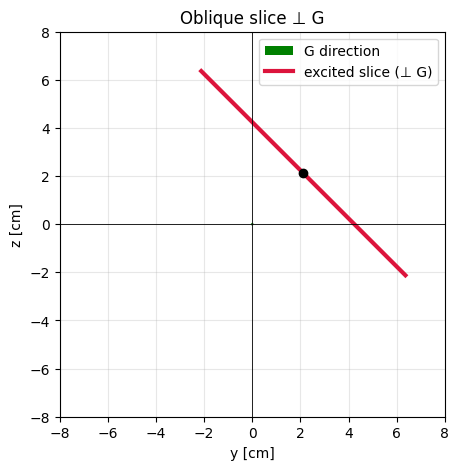

In [5]:
def oblique(G_vec_Tm, df_Hz):
    Gmag = np.linalg.norm(G_vec_Tm)
    eG   = np.array(G_vec_Tm, float)/Gmag
    dist = df_Hz/(GAMMA_BAR*Gmag)          # distance along eG
    return eG, Gmag, dist

# 45-degree oblique in the y-z plane
G_vec = np.array([0.0, 10e-3, 10e-3])      # |G| = 14.14 mT/m
df_ob = larmor_offset_Hz(np.linalg.norm(G_vec), 0.03)   # plane 3 cm out along eG
eG, Gmag, dist = oblique(G_vec, df_ob)
print(f"|G| = {Gmag*1e3:.2f} mT/m,  e_G = {np.round(eG,3)},  plane distance = {dist*100:.2f} cm")

# draw it (y horizontal, z vertical)
ey, ez = eG[1], eG[2]
center = dist*np.array([ey, ez])
perp = np.array([-ez, ey])                 # in-plane direction (perp to eG)
line = np.array([center - 0.06*perp, center + 0.06*perp])*100
plt.figure(figsize=(5,5))
plt.quiver(0,0, ey, ez, angles="xy", scale_units="xy", scale=14, color="green", label="G direction")
plt.plot(line[:,0], line[:,1], color="crimson", lw=3, label="excited slice (⊥ G)")
plt.plot(*(center*100), "ko")
plt.axhline(0, color="k", lw=.6); plt.axvline(0, color="k", lw=.6)
plt.gca().set_aspect("equal"); plt.xlim(-8,8); plt.ylim(-8,8)
plt.xlabel("y [cm]"); plt.ylabel("z [cm]"); plt.title("Oblique slice ⊥ G"); plt.legend(); plt.show()

## 5 · The sinc pulse and the rect↔sinc Fourier pair

A **rectangular frequency band** ↔ a **sinc in time**:

$$\mathcal F^{-1}\{\Pi(\nu;\nu_\text{center},\Delta\nu)\}=\Delta\nu\,\operatorname{sinc}(\pi t\,\Delta\nu)\,e^{i2\pi t\nu_\text{center}}.$$

A real pulse is **truncated**, so its spectrum has ripples and sloped shoulders — the reason
real slice profiles are never perfectly rectangular.

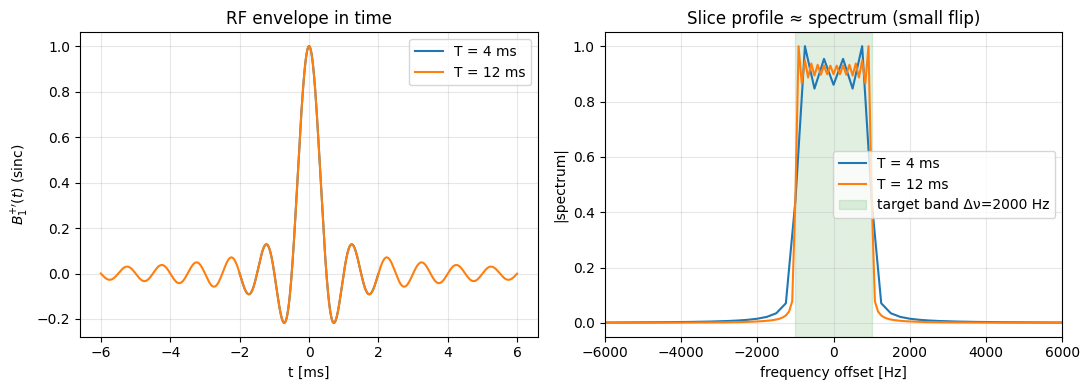

Longer pulse -> sharper, flatter band (closer to ideal rect).


In [6]:
def sinc_pulse(t, dnu):
    return np.sinc(t*dnu)        # numpy sinc(x)=sin(pi x)/(pi x) == sinc(pi t dnu)

dnu = 2000.0                     # target bandwidth [Hz]
fs  = 200e3
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for T, c in [(4e-3, "tab:blue"), (12e-3, "tab:orange")]:
    t  = np.arange(-T/2, T/2, 1/fs)
    b1 = sinc_pulse(t, dnu)
    B1 = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(b1)))
    f  = np.fft.fftshift(np.fft.fftfreq(len(t), 1/fs))
    mag = np.abs(B1); mag /= mag.max()
    ax[0].plot(t*1e3, b1, color=c, label=f"T = {T*1e3:.0f} ms")
    ax[1].plot(f, mag, color=c, label=f"T = {T*1e3:.0f} ms")
ax[0].set_xlabel("t [ms]"); ax[0].set_ylabel(r"$B_1^{+\prime}(t)$ (sinc)"); ax[0].set_title("RF envelope in time"); ax[0].legend()
ax[1].axvspan(-dnu/2, dnu/2, color="green", alpha=.12, label=f"target band Δν={dnu:.0f} Hz")
ax[1].set_xlim(-6000,6000); ax[1].set_xlabel("frequency offset [Hz]"); ax[1].set_ylabel("|spectrum|")
ax[1].set_title("Slice profile ≈ spectrum (small flip)"); ax[1].legend()
plt.tight_layout(); plt.show()
print("Longer pulse -> sharper, flatter band (closer to ideal rect).")

## 6 · Bloch slice-profile simulation — the small-flip-angle approximation

"Slice profile = Fourier transform of the pulse" is **only true for small flip angles**.
Here we simulate the Bloch equation directly (hard-pulse approximation): each spin at a
given off-resonance (≡ position) is rotated step-by-step about the instantaneous effective
field. Small flips give a near-rectangular slab; 90°/180° flips distort and ripple — which
is why large-flip pulses must be designed numerically.

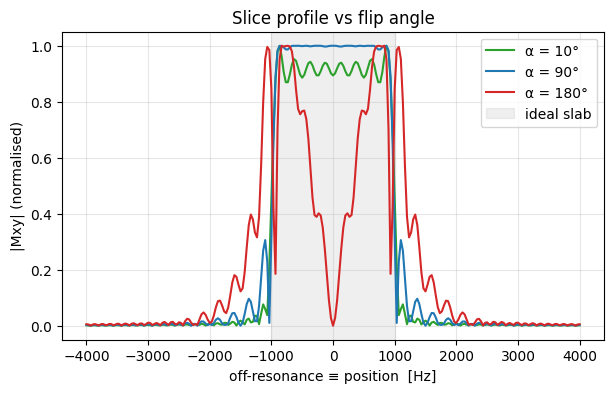

Small flip ≈ clean rect (FT rule holds). Large flip -> rounded, rippled, distorted.


In [7]:
def rotate_about(v, axis, angle):
    n = np.linalg.norm(axis)
    if n == 0: return v
    k = axis/n
    return v*np.cos(angle) + np.cross(k, v)*np.sin(angle) + k*np.dot(k, v)*(1-np.cos(angle))

def slice_profile(alpha_deg, dnu=2000., T=8e-3, N=400, fov_Hz=8000., npos=241):
    t   = np.linspace(-T/2, T/2, N); dt = t[1]-t[0]
    w1  = np.sinc(t*dnu)
    w1 *= np.deg2rad(alpha_deg)/(np.sum(w1)*dt)        # scale to desired on-res flip
    df  = np.linspace(-fov_Hz/2, fov_Hz/2, npos)       # off-resonance == position*gamma*G
    Mxy = np.empty(npos, complex)
    for i, fo in enumerate(df):
        woff = 2*np.pi*fo; M = np.array([0.,0.,1.])
        for n in range(N):
            Omega = np.array([w1[n], 0., woff])
            M = rotate_about(M, Omega, np.linalg.norm(Omega)*dt)
        Mxy[i] = M[0] + 1j*M[1]
    return df, Mxy

plt.figure()
for a, c in [(10,"tab:green"), (90,"tab:blue"), (180,"tab:red")]:
    df, mxy = slice_profile(a)
    prof = np.abs(mxy); prof = prof/prof.max()
    plt.plot(df, prof, color=c, label=f"α = {a}°")
plt.axvspan(-1000, 1000, color="grey", alpha=.12, label="ideal slab")
plt.xlabel("off-resonance ≡ position  [Hz]"); plt.ylabel("|Mxy| (normalised)")
plt.title("Slice profile vs flip angle"); plt.legend(); plt.show()
print("Small flip ≈ clean rect (FT rule holds). Large flip -> rounded, rippled, distorted.")

## 7 · The slice-rephasing gradient

After the (symmetric) slice-select lobe, spins across the slice have fanned out in phase
(`k_slice ≠ 0`) and the net signal collapses. A negative lobe of **half** the zeroth moment
rewinds `k_slice → 0` and refocuses them.

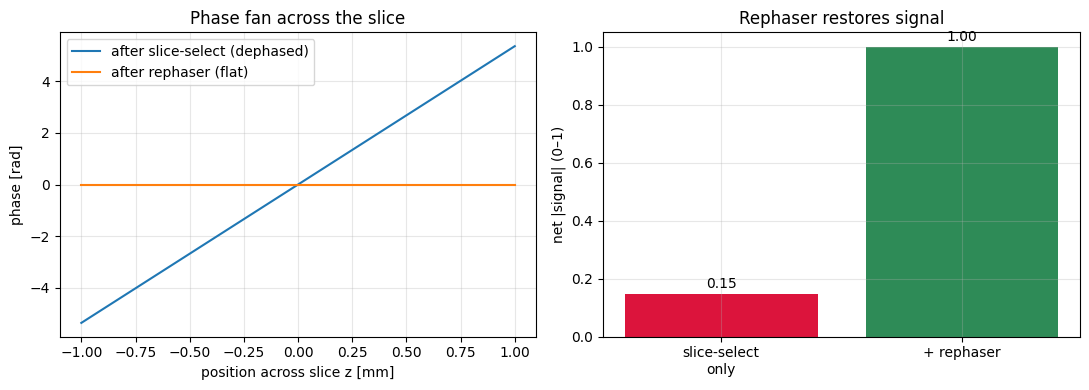

In [8]:
z   = np.linspace(-1e-3, 1e-3, 401)     # +/- 1 mm across the slice
G   = 10e-3
tau = 2e-3                               # winding time after pulse center

phi_after = GAMMA*G*z*tau                # linear phase across slice after slice-select
phi_reph  = phi_after - GAMMA*G*z*tau    # rephaser cancels the post-excitation winding
S_after = np.abs(np.mean(np.exp(1j*phi_after)))
S_reph  = np.abs(np.mean(np.exp(1j*phi_reph)))

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(z*1e3, np.unwrap(phi_after), label="after slice-select (dephased)")
ax[0].plot(z*1e3, phi_reph, label="after rephaser (flat)")
ax[0].set_xlabel("position across slice z [mm]"); ax[0].set_ylabel("phase [rad]")
ax[0].set_title("Phase fan across the slice"); ax[0].legend()
ax[1].bar(["slice-select\nonly","+ rephaser"], [S_after, S_reph], color=["crimson","seagreen"])
ax[1].set_ylabel("net |signal| (0–1)"); ax[1].set_title("Rephaser restores signal")
for i,v in enumerate([S_after, S_reph]): ax[1].text(i, v+.02, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()

## Exercise 11.1 — Slice selection 1 (worked numerically)

Build the three exercise quantities as reusable functions:

- gradient field `B_G(r) = (G·r) e_z`,
- center offset `(ν_center − ν₀) = γ̄ (G·r_center)`,
- bandwidth `Δν = γ̄ |G| Δx`,

then tabulate sagittal / coronal / axial / oblique cases.

> **Note on geometry:** read the *exact* slice positions off your copy of the sheet's figure
> and edit `center_pos` below. The representative positions here (5 cm, 10 cm, 45° oblique)
> demonstrate the method; the physics/answers scale linearly with position and thickness.

In [9]:
def exercise_11_1(G_mag, normal, center_pos, thickness):
    G_vec = G_mag*np.array(normal, float)/np.linalg.norm(normal)   # G points along slice normal
    df_center = GAMMA_BAR*np.dot(G_vec, center_pos)                # (nu_center - nu0)
    dnu       = GAMMA_BAR*np.linalg.norm(G_vec)*thickness          # bandwidth
    B_G_at_center = np.array([0,0, np.dot(G_vec, center_pos)])     # field is ALONG z
    return G_vec, B_G_at_center, df_center, dnu

cases = {
    "sagittal @ x=5cm":  ([1,0,0], [0.05,0,0]),
    "coronal  @ y=5cm":  ([0,1,0], [0,0.05,0]),
    "axial    @ z=5cm":  ([0,0,1], [0,0,0.05]),
    "axial    @ z=10cm": ([0,0,1], [0,0,0.10]),
    "oblique45@ 10cm":   ([0,1,1], None),
}
G = 10e-3
print(f"{'case':18s}  {'G [mT/m]':>16s}  {'(νc-ν0)[kHz]':>12s}  {'Δν2mm[Hz]':>9s}  {'Δν4mm[Hz]':>9s}")
for name,(normal,center) in cases.items():
    if center is None:
        n = np.array(normal,float)/np.linalg.norm(normal); center = (0.10*n).tolist()
    Gv,_,dfc,dn2 = exercise_11_1(G, normal, np.array(center,float), 2e-3)
    _,_,_,dn4    = exercise_11_1(G, normal, np.array(center,float), 4e-3)
    print(f"{name:18s}  {str(np.round(Gv*1e3,2)):>16s}  {dfc/1e3:12.2f}  {dn2:9.0f}  {dn4:9.0f}")

print("\nStronger / negative gradient (sagittal slice at 5 cm, 2 mm):")
for Gv_ in (20e-3, -10e-3):
    _,_,dfc,dn = exercise_11_1(Gv_, [1,0,0], np.array([0.05,0,0]), 2e-3)
    print(f"  G={Gv_*1e3:+.0f} mT/m -> (νc-ν0)={dfc/1e3:7.2f} kHz,  Δν(2mm)={dn:6.0f} Hz")

case                        G [mT/m]  (νc-ν0)[kHz]  Δν2mm[Hz]  Δν4mm[Hz]
sagittal @ x=5cm       [10.  0.  0.]         21.29        852       1703
coronal  @ y=5cm       [ 0. 10.  0.]         21.29        852       1703
axial    @ z=5cm       [ 0.  0. 10.]         21.29        852       1703
axial    @ z=10cm      [ 0.  0. 10.]         42.58        852       1703
oblique45@ 10cm     [0.   7.07 7.07]         42.58        852       1703

Stronger / negative gradient (sagittal slice at 5 cm, 2 mm):
  G=+20 mT/m -> (νc-ν0)=  42.58 kHz,  Δν(2mm)=  1703 Hz
  G=-10 mT/m -> (νc-ν0)= -21.29 kHz,  Δν(2mm)=   852 Hz


### Does `(ν_center − ν₀)` or `Δν` depend on B₀?

**No.** Both use only `γ̄`, `G` and geometry. `B₀` merely sets the absolute carrier `ν₀`.
Compute the *absolute* center frequencies at 1.5 T and 3 T to see the **offset** stay put:

In [10]:
G = 10e-3
_,_,df_center,dnu = exercise_11_1(G, [1,0,0], np.array([0.05,0,0]), 2e-3)
for B0 in (1.5, 3.0):
    nu0 = GAMMA_BAR*B0
    print(f"B0={B0} T: ν0={nu0/1e6:9.3f} MHz | "
          f"ν_center={(nu0+df_center)/1e6:9.3f} MHz | "
          f"(ν_center-ν0)={df_center/1e3:6.2f} kHz | Δν={dnu:5.0f} Hz")
print("-> ν0 changes with B0, but (ν_center-ν0) and Δν do NOT.")

B0=1.5 T: ν0=   63.866 MHz | ν_center=   63.888 MHz | (ν_center-ν0)= 21.29 kHz | Δν=  852 Hz
B0=3.0 T: ν0=  127.732 MHz | ν_center=  127.754 MHz | (ν_center-ν0)= 21.29 kHz | Δν=  852 Hz
-> ν0 changes with B0, but (ν_center-ν0) and Δν do NOT.


## Exercise 11.2 — Slice selection 2 (the "gymnastics")

Two perpendicular slice selections, both rotating about the **x′-axis** (right-handed),
starting from `M(0) = M₀ e_z`:

- **slice 1** sees only `α₁` (at `t₁ = 0`),
- **slice 2** sees only `α₂` (at `t₂ = 50 ms`),
- the **crossing region** sees `α₁` then `α₂`,
- the **rest of space** sees neither.

Compose rotation matrices `R_x(α)` (idealised: no relaxation/precession between pulses,
exactly as the sheet's hint assumes). We check against the provided hand-solution
`M(t_after α₁) = M(t_after α₂) = (0, −M₀, 0)ᵀ`.

In [11]:
def Rx(deg):
    a = np.deg2rad(deg)
    return np.array([[1,0,0],
                     [0,np.cos(a),-np.sin(a)],
                     [0,np.sin(a), np.cos(a)]])

M0 = 1.0
M_init = np.array([0,0,M0], float)

def regions(a1, a2):
    return dict(
        slice1   = Rx(a1) @ M_init,             # only alpha1
        slice2   = Rx(a2) @ M_init,             # only alpha2
        crossing = Rx(a2) @ (Rx(a1) @ M_init),  # alpha1 then alpha2
        rest     = M_init.copy(),               # neither
    )

for (a1, a2, label) in [(90,90,"(i)  α1=α2=90°"), (90,180,"(ii) α1=90°, α2=180°")]:
    print(f"case {label}")
    for k, v in regions(a1, a2).items():
        print(f"    {k:9s} M = ({v[0]:+.2f}, {v[1]:+.2f}, {v[2]:+.2f}) · M0")
    print()

# verify the sheet's given partial solution and full results
ri  = regions(90, 90)
assert np.allclose(ri['slice1'],   [0,-1,0])      # matches hint
assert np.allclose(ri['slice2'],   [0,-1,0])      # matches hint
assert np.allclose(ri['crossing'], [0,0,-1])
assert np.allclose(ri['rest'],     [0,0,1])
rii = regions(90, 180)
assert np.allclose(rii['slice1'],   [0,-1,0])
assert np.allclose(rii['slice2'],   [0,0,-1])
assert np.allclose(rii['crossing'], [0,1,0])
assert np.allclose(rii['rest'],     [0,0,1])
print("✓ Reproduces the sheet's hand-solution and completes both cases.")

case (i)  α1=α2=90°
    slice1    M = (+0.00, -1.00, +0.00) · M0
    slice2    M = (+0.00, -1.00, +0.00) · M0
    crossing  M = (+0.00, -0.00, -1.00) · M0
    rest      M = (+0.00, +0.00, +1.00) · M0

case (ii) α1=90°, α2=180°
    slice1    M = (+0.00, -1.00, +0.00) · M0
    slice2    M = (+0.00, -0.00, -1.00) · M0
    crossing  M = (+0.00, +1.00, -0.00) · M0
    rest      M = (+0.00, +0.00, +1.00) · M0

✓ Reproduces the sheet's hand-solution and completes both cases.


### Visualising the four magnetisation vectors (case ii)

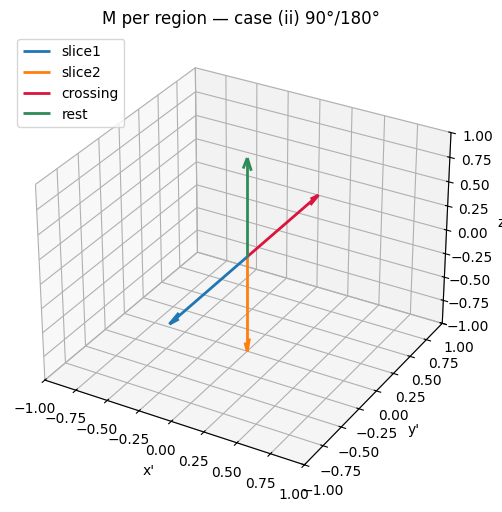

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
r = regions(90, 180)
fig = plt.figure(figsize=(7,6)); ax = fig.add_subplot(111, projection="3d")
colors = dict(slice1="tab:blue", slice2="tab:orange", crossing="crimson", rest="seagreen")
for k, v in r.items():
    ax.quiver(0,0,0, v[0], v[1], v[2], color=colors[k], lw=2, label=k, arrow_length_ratio=.12)
ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_zlim(-1,1)
ax.set_xlabel("x'"); ax.set_ylabel("y'"); ax.set_zlabel("z'")
ax.set_title("M per region — case (ii) 90°/180°"); ax.legend(loc="upper left"); plt.show()

## Try it yourself

- In **§3**, fix a slice thickness (say 3 mm) and solve for the gradient at several bandwidths — confirm the `1/G` law by eye.
- In **§6**, push the flip angle to 120° or 200° and watch the profile degrade. Then lengthen the pulse `T` (more sinc lobes) and see the small-flip profile sharpen.
- In **§7**, make the rephaser *imperfect* (cancel only 80 % of the winding) and watch the recovered signal drop.
- In **Exercise 11.1**, edit `center_pos` to the exact positions on your sheet and re-run the table.
- In **Exercise 11.2**, try `α₂ = 270°` or a y′-axis rotation and predict the crossing region before running.

### Self-test (answers in `L11_summary.md`)
1. Why does a stronger gradient give a *thinner* slice? 2. Why is `B_G` always ∥ `e_z`?
3. What three features of the sinc pulse set flip angle, slice center, and thickness?
4. When does "profile = FT of pulse" break, and why? 5. What does the rephaser do in k-space?
